In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import psutil  # Pour vérifier la RAM disponible

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Charger le CSV depuis Drive
df = pd.read_csv('/content/drive/MyDrive/merged_feature_inbalanced.csv')
df.head()


Mounted at /content/drive


,latitude,longitude,TEB_log,CEC_CLAY,GYPSUM_log,TEXTURE_SOTER_encoded,ORG_CARBON_log,LCCCODE_encoded,ELEC_COND_log,COARSE,TEXTURE_USDA_encoded,prec,elevation_scaled,tmean,trange,class
0,1.599941,0.424514,-0.873085,-0.186051,-0.359351,0.414534,0.923640,-1.239120,-0.436378,0.537499,0.737545,3.782619,-1.221677,-0.792786,-1.908889,1
1,1.008210,-0.100769,0.326187,-0.472797,0.205265,0.414534,0.430136,-1.002590,0.023074,-0.631298,-0.074938,0.084922,0.499363,-0.337188,-0.914481,1
2,0.890917,0.214921,0.326187,-0.472797,0.205265,0.414534,0.430136,0.534857,0.023074,-0.631298,-0.074938,0.380618,3.055712,-1.835239,-0.022087,1
3,-1.445041,-0.234935,0.326187,0.846235,-0.204527,0.414534,0.153275,0.771388,0.428338,-1.020897,0.737545,-0.943846,-0.252101,1.135902,0.047433,1
4,-1.360532,-0.229133,0.326187,0.846235,-0.204527,0.414534,0.153275,-1.002590,0.428338,-1.020897,0.737545,-0.931629,-0.304104,1.107084,-0.154453,1


In [3]:
X = df.drop('class', axis=1).values
y = df['class'].values

In [4]:
print("📌 Distribution du dataset (inbalance) :")
print(pd.Series(y).value_counts())

📌 Distribution du dataset (inbalance) :
0    112132
1     28033
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Nombre de points train : {X_train.shape[0]}")
print(f"Nombre de points test  : {X_test.shape[0]}")


Nombre de points train : 98115
Nombre de points test  : 42050


In [9]:
ram_bytes = psutil.virtual_memory().available
batch_size = max(100, int((ram_bytes*0.5)/(X_train.shape[1]*X_train.shape[0]*8)))
print(f"RAM disponible : {ram_bytes/(1024**2):.1f} MB")
print(f"Batch size utilisé : {batch_size}")


RAM disponible : 11360.2 MB
Batch size utilisé : 505


In [6]:

def knn_predict_batch(X_train, y_train, X_test, k=3, batch_size=500, metric='euclidean'):
    y_pred = []
    num_test = X_test.shape[0]

    for start in range(0, num_test, batch_size):
        end = min(start + batch_size, num_test)
        X_batch = X_test[start:end]

        # Distance
        if metric == 'euclidean':
            dists = np.sqrt(((X_batch[:, np.newaxis, :] - X_train[np.newaxis, :, :])**2).sum(axis=2))
        elif metric == 'manhattan':
            dists = np.abs(X_batch[:, np.newaxis, :] - X_train[np.newaxis, :, :]).sum(axis=2)
        else:
            raise ValueError("Metric not supported")

        # Voisins
        nearest = np.argsort(dists, axis=1)[:, :k]

        # Vote majoritaire
        batch_pred = [np.argmax(np.bincount(y_train[neighbors])) for neighbors in nearest]
        y_pred.extend(batch_pred)

    return np.array(y_pred)

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Définir les k à tester
k_values = [1,3, 5, 7, 9]  # <- important ! à définir avant la boucle
results_sklearn = []

for k in k_values:
    # KNN avec pondération par distance (recommandé pour dataset inbalance)
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance', n_jobs=-1)

    start_time = time.time()
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    duration = time.time() - start_time

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"[Scikit-Learn] k={k} | Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, Time={duration:.1f}s")
    results_sklearn.append((k, acc, prec, rec, f1, duration))


[Scikit-Learn] k=1 | Acc=0.9752, Prec=0.9243, Rec=0.9540, F1=0.9389, Time=3.1s
[Scikit-Learn] k=3 | Acc=0.9777, Prec=0.9400, Rec=0.9492, F1=0.9446, Time=3.7s
[Scikit-Learn] k=5 | Acc=0.9784, Prec=0.9466, Rec=0.9452, F1=0.9459, Time=6.2s
[Scikit-Learn] k=7 | Acc=0.9781, Prec=0.9482, Rec=0.9422, F1=0.9452, Time=4.5s
[Scikit-Learn] k=9 | Acc=0.9781, Prec=0.9499, Rec=0.9403, F1=0.9451, Time=4.9s


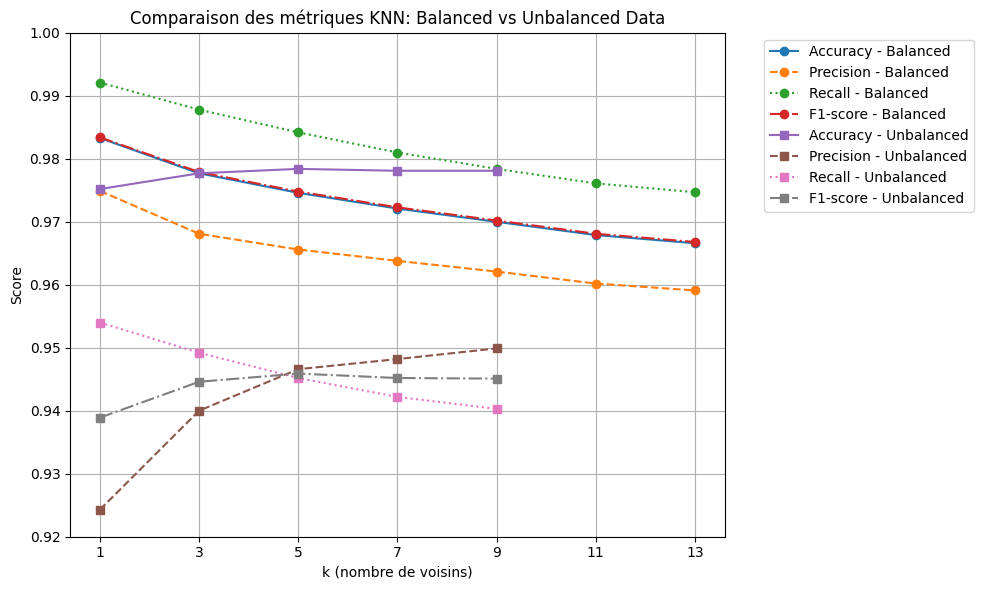

In [3]:
import matplotlib.pyplot as plt

# Valeurs de k
k_balanced = [1, 3, 5, 7, 9, 11, 13]
k_unbalanced = [1, 3, 5, 7, 9]

# Métriques pour les données équilibrées
acc_balanced = [0.9833, 0.9777, 0.9746, 0.9721, 0.9700, 0.9679, 0.9666]
prec_balanced = [0.9749, 0.9681, 0.9656, 0.9638, 0.9621, 0.9602, 0.9591]
rec_balanced = [0.9921, 0.9878, 0.9842, 0.9810, 0.9784, 0.9761, 0.9747]
f1_balanced = [0.9834, 0.9779, 0.9748, 0.9723, 0.9702, 0.9681, 0.9668]

# Métriques pour les données non équilibrées
acc_unbalanced = [0.9752, 0.9777, 0.9784, 0.9781, 0.9781]
prec_unbalanced = [0.9243, 0.9400, 0.9466, 0.9482, 0.9499]
rec_unbalanced = [0.9540, 0.9492, 0.9452, 0.9422, 0.9403]
f1_unbalanced = [0.9389, 0.9446, 0.9459, 0.9452, 0.9451]

# Création du graphique
plt.figure(figsize=(10,6))

# Balanced
plt.plot(k_balanced, acc_balanced, marker='o', label='Accuracy - Balanced')
plt.plot(k_balanced, prec_balanced, marker='o', linestyle='--', label='Precision - Balanced')
plt.plot(k_balanced, rec_balanced, marker='o', linestyle=':', label='Recall - Balanced')
plt.plot(k_balanced, f1_balanced, marker='o', linestyle='-.', label='F1-score - Balanced')

# Unbalanced
plt.plot(k_unbalanced, acc_unbalanced, marker='s', label='Accuracy - Unbalanced')
plt.plot(k_unbalanced, prec_unbalanced, marker='s', linestyle='--', label='Precision - Unbalanced')
plt.plot(k_unbalanced, rec_unbalanced, marker='s', linestyle=':', label='Recall - Unbalanced')
plt.plot(k_unbalanced, f1_unbalanced, marker='s', linestyle='-.', label='F1-score - Unbalanced')

plt.title('Comparaison des métriques KNN: Balanced vs Unbalanced Data')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('Score')
plt.xticks(k_balanced)
plt.ylim(0.92, 1.0)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
